# Exercise 4

## FE class

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plot_structure_def import plot_structure_def

def eucl_dist(p1, p2):
    x1, z1 = p1
    x2, z2 = p2
    return np.sqrt((x2-x1)**2 + (z2-z1)**2)

def check_symmetric(a, rtol=1e-05, atol=1e-08):
    return np.allclose(a, a.T, rtol=rtol, atol=atol)


class Node:

    def __init__(self, x: float, z: float, fixed=None):
        self.x = x
        self.z = z
        self.fixed = fixed if fixed is not None else [] # 0 -> x fixed, 1 -> z fixed, 2 -> theta fixed
        self.dofs = []
    
    def __str__(self) -> str:
        bcond = ""
        if self.fixed is not []:
            for i in self.fixed:
                match i:
                    case 0:
                        bcond += "x "
                    case 1:
                        bcond += "z "
                    case 2:
                        bcond += "theta"
            return f"Node at x={self.x} and z={self.z} with fixed {bcond}" 
        return f"Node at x={self.x} and z={self.z}"

class Element:

    def __init__(self, n1, n2, E, I, A):
        self.n1 = n1
        self.n2 = n2
        self.E = E
        self.I = I
        self.A = A
        self.L = eucl_dist([n1.x, n1.z], [n2.x, n2.z]) # calc length
        self.psi = np.atan2(self.n2.z-self.n1.z, self.n2.x-self.n1.x) # calc angle

        Tgs = np.array([[np.cos(self.psi), np.sin(self.psi), 0], [-np.sin(self.psi), np.cos(self.psi), 0], [0, 0, 1]])

        self.Tg = np.zeros((6, 6))# global transformation mat
        self.Tg[0:3, 0:3] = Tgs
        self.Tg[3:6, 3:6] = Tgs

        k_loc = self.get_k_local()
        self.k_gl = self.Tg.T @ k_loc @ self.Tg
    
    def get_k_local(self) -> np.array:
        L, A, I, E = self.L, self.A, self.I, self.E
        mu = A*L**2/I
        k_loc = E * I / L**3 * np.array([
            [mu,  0,       0,      -mu,  0,       0     ],
            [0,   12,     -6*L,     0,  -12,     -6*L   ],
            [0,  -6*L,     4*L**2,  0,   6*L,     2*L**2],
            [-mu, 0,       0,       mu,  0,       0     ],
            [0,  -12,      6*L,     0,   12,      6*L   ],
            [0,  -6*L,     2*L**2,  0,   6*L,     4*L**2]
        ])
        
        return k_loc
    
    def __str__(self):
        return f"Element with L={self.L}, E={self.E}, I={self.I} and A={self.A} and Nodes:\n\t{self.n1.__str__()}\n\t{self.n2.__str__()}\nangle={self.psi}\n"


class NodalLoad:

    def __init__(self, node: Node, Fx=0, Fz=0, M=0):
        self.node = node
        self.Fx = Fx
        self.Fz = Fz
        self.M = M


class DistributedLoad:

    def __init__(self, element: Element, qz=0):
        # qz is the uniform load perpendicular to the local element axis (e.g., N/m)
        self.element = element
        self.qz = qz
        
    def get_equivalent_nodal_forces(self) -> np.array:
        L = self.element.L
        q = self.qz
        

        R_loc = np.array([
            0,             # local x1
            -q * L / 2,     # local z1
            q * L**2 / 12, # local theta1
            0,             # local x2
            -q * L / 2,     # local z2
            -q * L**2 / 12 # local theta2
        ])
        
        # transf local forces to global 
        R_glob = self.element.Tg.T @ R_loc
        return R_glob


class System:

    def __init__(self, elements:list, loads:list=None, nodes:list=None):
        self.elements = elements
        self.loads = loads if loads is not None else []

        if nodes is not None:
            self.nodes = nodes
        else:
            self.nodes = []

            # find unique nodes
            for el in elements:
                for candidate in (el.n1, el.n2):
                    # only add candidate if not already in
                    if candidate not in self.nodes:
                        self.nodes.append(candidate)
        
        for idx, node in enumerate(self.nodes):
            node.dofs = [0+idx*3, 1+idx*3, 2+idx*3]
        
    
    def assemble(self):
        total_dofs = 3*len(self.nodes)

        # initn displacement vecg
        self.r = np.zeros(total_dofs)

        # stiffness mat
        K_glob = np.zeros((total_dofs, total_dofs))

        for el in self.elements:
            dofs = el.n1.dofs + el.n2.dofs
            K_glob[np.ix_(dofs, dofs)] += el.k_gl
            
        self.K_glob = K_glob
        
        # force vec
        self.R_glob = np.zeros(total_dofs)

        for load in self.loads:
            if isinstance(load, NodalLoad):
                dofs = load.node.dofs
                self.R_glob[dofs[0]] += load.Fx
                self.R_glob[dofs[1]] += load.Fz
                self.R_glob[dofs[2]] += load.M

            elif isinstance(load, DistributedLoad):
                R_eq = load.get_equivalent_nodal_forces()
                dofs = load.element.n1.dofs + load.element.n2.dofs
                self.R_glob[dofs] += R_eq


    def apply_bcs(self):
        fixed_dofs = []
        for node in self.nodes:
            for fixed_idx in node.fixed:
                fixed_dofs.append(node.dofs[fixed_idx])
        
        self.K_solve = np.copy(self.K_glob)
        for dof in fixed_dofs:
            self.K_solve[dof, :] = 0.0  # zero in row
            self.K_solve[:, dof] = 0.0  # zero in col
            self.K_solve[dof, dof] = 1.0  # set diag to 1
            
            self.R_glob[dof] = 0.0 
            
        return self.K_glob, self.R_glob
    

    def solve(self):
        self.r = np.linalg.solve(self.K_solve, self.R_glob)
        return self.r

    def get_bandwidth(self):
        pass
    
    
    def __str__(self):
        elstr = ""
        for el in self.elements:
            elstr += el.__str__()

        return f"System containing {len(self.elements)} elements:\n{elstr}"


## Problem 1
### a) first numbering scheme

displacement in x at node 11: 0.07083604652936105


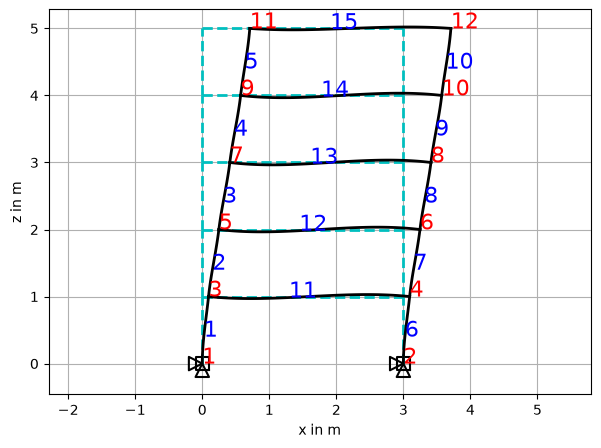

In [2]:
a = 1 # m
E = 1e4 # Pa
Iv = 1 # m⁴     vertical stiffn = EI = 1e4
Ih = 2 # m⁴     horizontal stiffn = 2*EI = 2e4

mu = 1e6
Ah = mu*Ih/(3*a)**2 # m²
Av = mu*Iv/a**2   # m²


H = 1000 # N

n1 = Node(0, 0, fixed=[0, 1, 2])
n2 = Node(3*a, 0, fixed=[0, 1, 2])
n3 = Node(0, 1*a)
n4 = Node(3*a, 1*a)
n5 = Node(0, 2*a)
n6 = Node(3*a, 2*a)
n7 = Node(0, 3*a)
n8 = Node(3*a, 3*a)
n9 = Node(0, 4*a)
n10 = Node(3*a, 4*a)
n11 = Node(0, 5*a)
n12 = Node(3*a, 5*a)

# vertical el
el1 = Element(n1, n3, E, Iv, Av)
el2 = Element(n3, n5, E, Iv, Av)
el3 = Element(n5, n7, E, Iv, Av)
el4 = Element(n7, n9, E, Iv, Av)
el5 = Element(n9, n11, E, Iv, Av)
el6 = Element(n2, n4, E, Iv, Av)
el7 = Element(n4, n6, E, Iv, Av)
el8 = Element(n6, n8, E, Iv, Av)
el9 = Element(n8, n10, E, Iv, Av)
el10 = Element(n10, n12, E, Iv, Av)

# horizontal el
el11 = Element(n3, n4, E, Ih, Ah)
el12 = Element(n5, n6, E, Ih, Ah)
el13 = Element(n7, n8, E, Ih, Ah)
el14 = Element(n9, n10, E, Ih, Ah)
el15 = Element(n11, n12, E, Ih, Ah)

#el16 = Element(n2,n3, E, I, A)

nl11 = NodalLoad(n11, Fx=H, Fz=0, M=0)

orderednodes = [n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11, n12]
elements = [el1, el2, el3, el4, el5, el6, el7, el8, el9, el10, el11, el12, el13, el14, el15]
loads = [nl11]
sys = System(elements, loads=loads, nodes=orderednodes)

sys.assemble()
sys.apply_bcs()

r = sys.solve()
print(f'displacement in x at node 11: {r[11*3]}')
fig1 = plot_structure_def(sys, 10, supports=True)

### c.1) numbering scheme 1

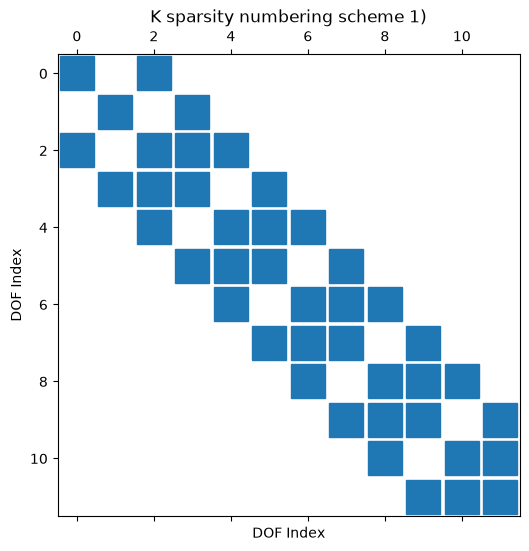

In [3]:
n_size = sys.K_solve.shape[0] // 3
K_simple = np.zeros((n_size, n_size))

for i in range(sys.K_glob.shape[0]):
    for j in range(sys.K_glob.shape[1]):
        if sys.K_glob[i, j] > 1e-6:
            K_simple[i // 3, j // 3] = 1

plt.figure(figsize=(6, 6))
plt.spy(K_simple, precision=0, markersize=25)
plt.title("K sparsity numbering scheme 1)")
plt.xlabel("DOF Index")
plt.ylabel("DOF Index")
plt.show()

### b) different numbering scheme

displacement in x at node 6: 0.070836046529841


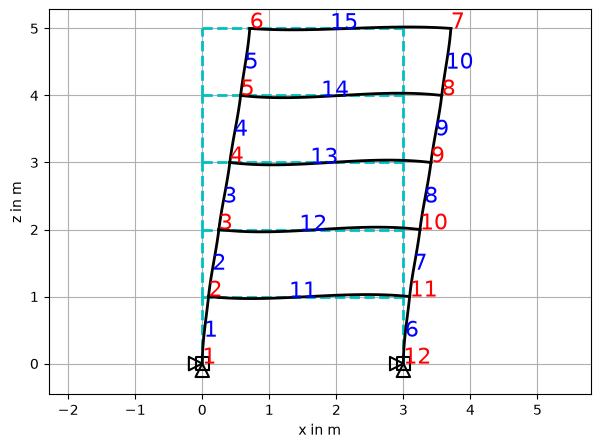

In [4]:
n1 = Node(0, 0, fixed=[0, 1, 2])
n12 = Node(3*a, 0, fixed=[0, 1, 2])
n2 = Node(0, 1*a)
n11 = Node(3*a, 1*a)
n3 = Node(0, 2*a)
n10 = Node(3*a, 2*a)
n4 = Node(0, 3*a)
n9 = Node(3*a, 3*a)
n5 = Node(0, 4*a)
n8 = Node(3*a, 4*a)
n6 = Node(0, 5*a)
n7 = Node(3*a, 5*a)

# vertical el
el1 = Element(n1, n2, E, Iv, Av)
el2 = Element(n2, n3, E, Iv, Av)
el3 = Element(n3, n4, E, Iv, Av)
el4 = Element(n4, n5, E, Iv, Av)
el5 = Element(n5, n6, E, Iv, Av)
el6 = Element(n12, n11, E, Iv, Av)
el7 = Element(n11, n10, E, Iv, Av)
el8 = Element(n10, n9, E, Iv, Av)
el9 = Element(n9, n8, E, Iv, Av)
el10 = Element(n8, n7, E, Iv, Av)

# horizontal el
el11 = Element(n2, n11, E, Ih, Ah)
el12 = Element(n3, n10, E, Ih, Ah)
el13 = Element(n4, n9, E, Ih, Ah)
el14 = Element(n5, n8, E, Ih, Ah)
el15 = Element(n6, n7, E, Ih, Ah)

#el16 = Element(n2,n3, E, I, A)

nl6 = NodalLoad(n6, Fx=H, Fz=0, M=0)

orderednodes = [n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11, n12]
elements = [el1, el2, el3, el4, el5, el6, el7, el8, el9, el10, el11, el12, el13, el14, el15]
loads = [nl6]
sys = System(elements, loads=loads, nodes=orderednodes)

sys.assemble()
sys.apply_bcs()

r = sys.solve()
print(f'displacement in x at node 6: {r[6*3]}')
fig1 = plot_structure_def(sys, 10, supports=True)

### c.2) numbering scheme 2

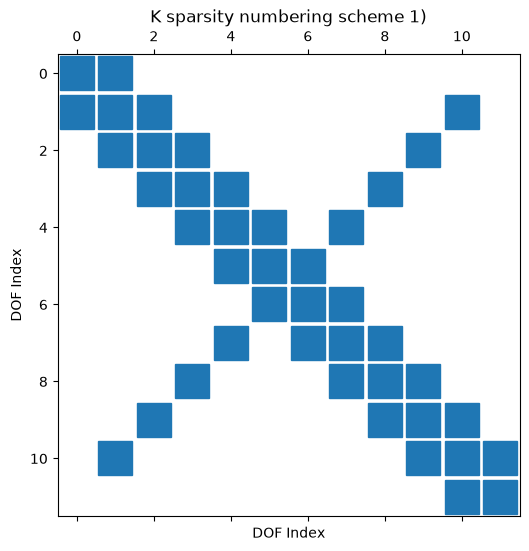

In [5]:
n_size = sys.K_solve.shape[0] // 3
K_simple = np.zeros((n_size, n_size))

for i in range(sys.K_glob.shape[0]):
    for j in range(sys.K_glob.shape[1]):
        if sys.K_glob[i, j] > 1e-6:
            K_simple[i // 3, j // 3] = 1

plt.figure(figsize=(6, 6))
plt.spy(K_simple, precision=0, markersize=25)
plt.title("K sparsity numbering scheme 1)")
plt.xlabel("DOF Index")
plt.ylabel("DOF Index")
plt.show()

### d)

displacement in x at node 11: 0.0


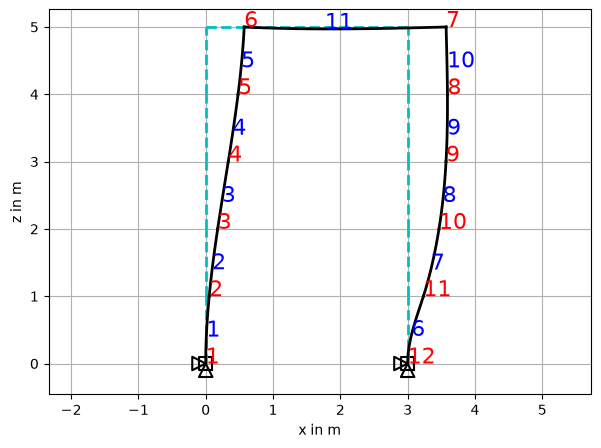

In [6]:
orderednodes = [n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11, n12]
elements = [el1, el2, el3, el4, el5, el6, el7, el8, el9, el10, el15]
loads = [nl11]
sys = System(elements, loads=loads, nodes=orderednodes)

sys.assemble()
sys.apply_bcs()

r = sys.solve()
print(f'displacement in x at node 11: {r[11*3]}')
fig1 = plot_structure_def(sys, 10, supports=True)